# 01 — Complex spectrum and edge modes

The finite OBC spectrum contains two boundary modes: a **protected** mode on the
lossless A sublattice (`Re(E)=0`, `Im(E)≈0`) and a **lossy** mode on the B
sublattice (`Im(E)≈-gamma`). Bulk modes share `Im(E)=-gamma/2`.

In [1]:
import sys; sys.path.insert(0, "../src")
import numpy as np, matplotlib.pyplot as plt
import nh_topo as nt
from nh_topo import plotting as P
cfg = nt.load_all(config_dir="../config"); p = nt.get_physics_params(cfg)
from pathlib import Path
def figdir(key): return Path("..") / nt.get_figure_dir(cfg, key)
print(f"t1={p['t1']}, t2={p['t2']}, gamma={p['gamma']}, N={p['N']}, "
      f"|nu|={nt.topological_invariant(p['t1'], p['t2'])}")

t1=0.8, t2=1.2, gamma=0.3, N=20, |nu|=1


protected edge E = [-0.-0.j]
lossy     edge E = [-0.-0.3j]
Im(E) range = [-0.3000, -0.0000]


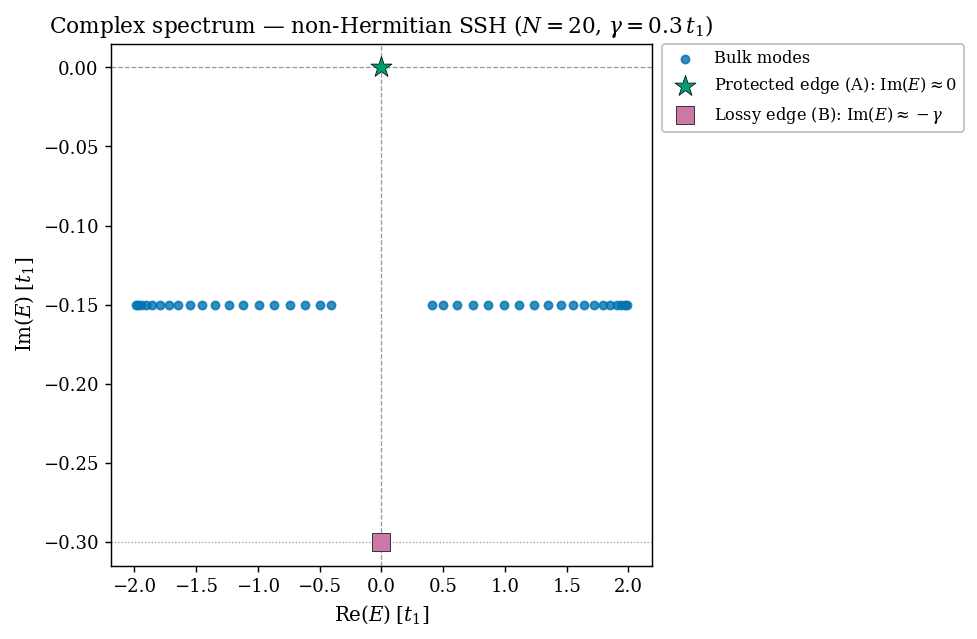

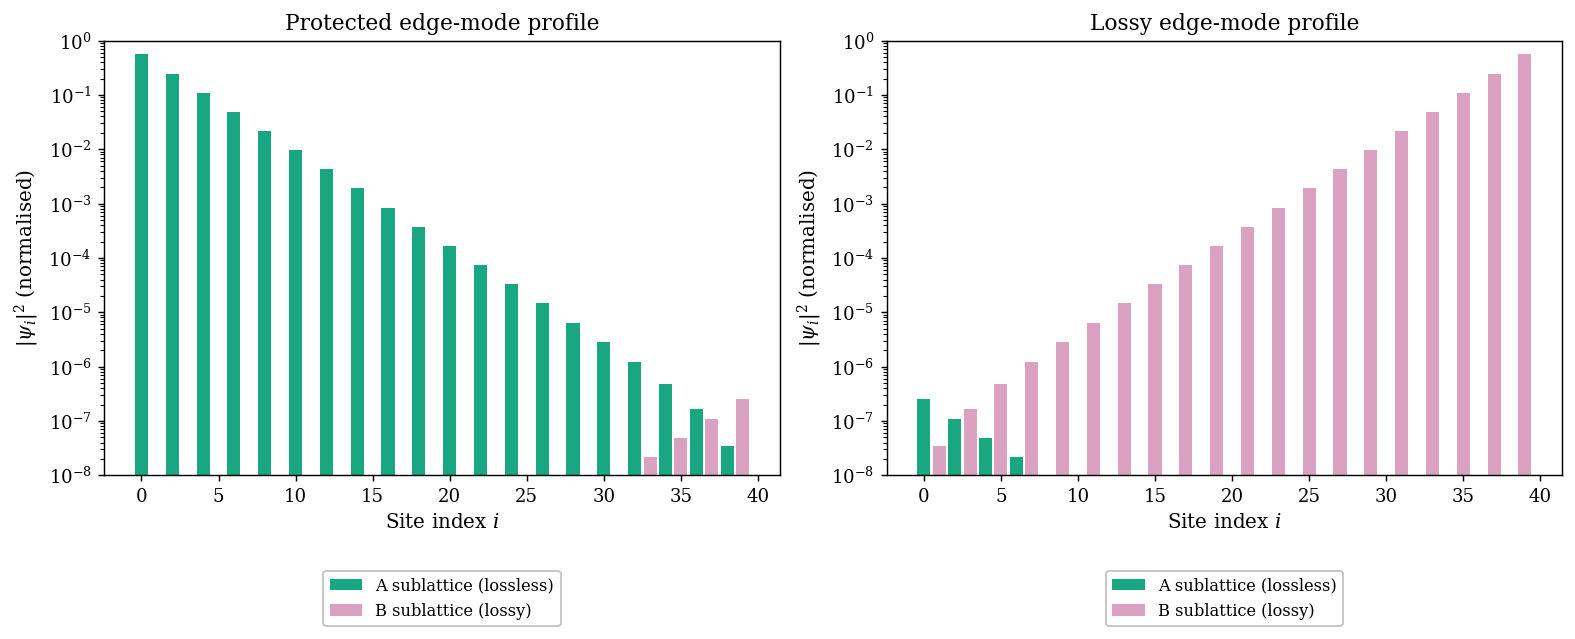

In [2]:
H = nt.build_ssh(p["N"], p["t1"], p["t2"], p["gamma"])
evals, evecs = nt.diagonalize(H)
info = nt.find_edge_modes(evals, evecs)
print("protected edge E =", np.round(info["protected_evals"], 6))
print("lossy     edge E =", np.round(info["lossy_evals"], 6))
print("Im(E) range = [%.4f, %.4f]" % (evals.imag.min(), evals.imag.max()))
bio = nt.biorthogonal_density(evecs)
fig, _ = P.plot_complex_spectrum(evals, info, p["N"], p["gamma"])
P.save_fig(fig, figdir("01_theory_nonhermitian_lattices"), "01_complex_spectrum"); plt.show()
fig, _ = P.plot_edge_profile(bio, evecs, info, p["N"])
P.save_fig(fig, figdir("01_theory_nonhermitian_lattices"), "02_edge_profiles"); plt.show()

**Reading the figures.** The protected mode decays exponentially into the
bulk on A sites with negligible B weight — which is precisely *why* it avoids the
loss channel and stays at `Im(E)≈0`. Reciprocal hopping rules out the skin
effect as the origin of localization.